# Final Project Notebook

DS 5001 Text as Data

# Metadata

- Full Name: <span style="color:red"> Muhammad Amjad <span>
- Userid: <span style="color:red"> mta4kd <span>
- GitHub Repo URL:<span style="color:red"> https://github.com/mta4kd/Text-as-Data-Project <span>
- UVA Box URL: https://app.box.com/s/k7697tzgdnxmtqk6skgqot6yv0caeehe

# Overview

The goal of the final project is for you to create a **digital analytical edition** of a corpus using the tools, practices, and perspectives you’ve learning in this course. You will select a corpus that has already been digitized and transcribed, parse that into an F-compliant set of tables, and then generate and visualize the results of a series of fitted models. You will also draw some tentative conclusions regarding the linguistic, cultural, psychological, or historical features represented by your corpus. The point of the exercise is to have you work with a corpus through the entire pipeline from ingestion to interpretation. 

Specifically, you will acquire a collection of long-form texts and perform the following operations:

- **Convert** the collection from their source formats (F0) into a set of tables that conform to the Standard Text Analytic Data Model (F2).
- **Annotate** these tables with statistical and linguistic features using NLP libraries such as NLTK (F3).
- **Produce** a vector representation of the corpus to generate TFIDF values to add to the TOKEN (aka CORPUS) and VOCAB tables (F4).
- **Model** the annotated and vectorized model with tables and features derived from the application of unsupervised methods, including PCA, LDA, and word2vec (F5).
- **Explore** your results using statistical and visual methods.
- **Present** conclusions about patterns observed in the corpus by means of these operations.

When you are finished, you will make the results of your work available in GitHub (for code) and UVA Box (for data). You will submit to Gradescope (via Canvas) a PDF version of a Jupyter notebook that contains the information listed below.

# Some Details

- Please fill out your answers in each task below by editing the markdown cell. 
- Replace text that asks you to insert something with the thing, i.e. replace `(INSERT IMAGE HERE)` with an image element, e.g. `![](image.png)`.
- For URLs, just paste the raw URL directly into the text area. Don't worry about providing link labels using `[label](link)`.
- Please do not alter the structure of the document or cell, i.e. the bulleted lists. 
- You may add explanatory paragraphs below the bulleted lists.
- Please name your tables as they are named in each task below.
- Tasks are indicated by headers with point values in parentheses.

# Raw Data

## Source Description (1)

Provide a brief description of your source material, including its provenance and content. Tell us where you found it and what kind of content it contains.

<span style="color:red">

The source material for this project comes from Project Gutenberg, a publicly accessible digital archive of texts in the public domain. I construct two large, comparable corpora using the complete short fiction of Edgar Allan Poe and Nathaniel Hawthorne, rather than a small curated subset of stories.

For Poe, I include the full set of his short stories drawn from collected works available through Project Gutenberg, capturing his focus on psychological horror, unreliable narration, and intense emotional states centered around themes such as madness, death, and fear. For Hawthorne, I similarly compile a broad set of his short stories from collections such as Twice-Told Tales and Mosses from an Old Manse, which emphasize moral and religious themes, including sin, guilt, secrecy, and the human condition through symbolic and allegorical storytelling.

By expanding beyond a small sample to include the majority of each author’s short fiction, the combined dataset scales to several hundred thousand words, satisfying the required token range for analysis. At the same time, the corpora remain well-matched in genre, time period, and format—19th-century American short fiction—allowing for a structured comparison of two distinct but related approaches to Gothic literature: Poe’s emphasis on internal psychological experience and Hawthorne’s emphasis on moral and philosophical reflection.

<span>

## Source Features (1)

Add values for the following items. (Do this for all following bulleted lists.)

- Source URL: <span style="color:red"> Poe: https://www.gutenberg.org/cache/epub/2148/pg2148.txt, https://www.gutenberg.org/cache/epub/2147/pg2147.txt | Hawthorne: https://www.gutenberg.org/files/59280/59280-h/59280-h.htm <span>
- UVA Box URL: https://app.box.com/s/ub5fk812k15gu1y7svcb3534if1ouv2z
- Number of raw documents: <span style="color:red"> 65 total documents: 25 from Poe and 40 from Hawthorne <span>
- Total size of raw documents (e.g. in MB): <span style="color:red"> ~2MB <span>
- File format(s), e.g. XML, plaintext, etc.: <span style="color:red"> plaintext (Poe), HTML (Hawthorne) <span>

## Source Document Structure (1)

Provide a brief description of the internal structure of each document. That, describe the typical elements found in document and their relation to each other. For example, a corpus of letters might be described as having a date, an addressee, a salutation, a set of content paragraphs, and closing. If they are various structures, state that.

<span style="color:red"> 

The corpus consists of short stories by Edgar Allan Poe and Nathaniel Hawthorne sourced from Project Gutenberg in two different formats: a plain text file (Poe) and HTML-based collections (Hawthorne). Despite formatting differences, the internal structure of the documents is largely consistent across both authors.

Each document (i.e., each short story) follows a standard narrative structure. Stories typically begin with a title header, followed by the main narrative text, which is organized into paragraphs. Some stories include brief introductory framing or scene-setting, often establishing the narrator, tone, or setting early on, particularly in Poe’s works, which frequently open with psychological or atmospheric context.

The body of each story consists of continuous prose paragraphs, sometimes interspersed with dialogue. There are no formal sections or chapters within individual stories, as each is designed to be read in a single sitting and to produce a unified effect. The narrative typically progresses linearly from exposition to climax and resolution.

In the Hawthorne source, multiple stories are accessed through Project Gutenberg HTML files, which may either embed several stories within a single document or link to individual story pages within a collection. In either case, stories are organized around clear title headers and can be segmented into individual documents based on these boundaries. In contrast, the Poe source is a plaintext compilation where stories are listed sequentially and separated by titles and line breaks.

Overall, while the file formats differ (HTML vs. plaintext), the internal structure of each document is consistent: title → narrative prose (paragraphs and occasional dialogue) → conclusion, with no additional metadata or structural elements embedded within individual stories.
<span>

# Parsed and Annotated Data

Parse the raw data into the three core tables of your addition: the `LIB`, `CORPUS`, and `VOCAB` tables.

These tables will be stored as CSV files with header rows.

You may consider using `|` as a delimitter.

Provide the following information for each.

## LIB (2)

The source documents the corpus comprises. These may be books, plays, newspaper articles, abstracts, blog posts, etc. 

Note that these are *not* documents in the sense used to describe a bag-of-words representation of a text, e.g. chapter.

- UVA Box URL: https://app.box.com/s/xom6qk4vugsxzdp2q02noqafmvic5hps
- GitHub URL for notebook used to create:
- Delimitter: 
- Number of observations:
- List of features, including at least three that may be used for model summarization (e.g. date, author, etc.):
- Average length of each document in characters: 

In [1]:
import re
import pandas as pd
from bs4 import BeautifulSoup

In [2]:
def clean_text(x):
    x = x.replace("\r", "\n")
    x = re.sub(r"\n{3,}", "\n\n", x)
    x = re.sub(r"[ \t]+", " ", x)
    return x.strip()

In [3]:
def clean_title(t):
    t = str(t)
    t = t.replace("\\n", " ")
    t = t.replace("\n", " ")
    t = re.sub(r"\[\d+\]", "", t)
    t = re.sub(r"(?i)^\s*(i|ii|iii|iv|v|vi|vii|viii|ix|x)\.\s*", "", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip().title()

In [4]:
def find_nth(text, pattern, n=2):
    matches = list(re.finditer(re.escape(pattern), text, flags=re.I))
    if len(matches) >= n:
        return matches[n-1].start()
    return None

In [5]:
def extract_txt_stories_second_occurrence(path, titles, author):
    with open(path, encoding="utf-8") as f:
        text = clean_text(f.read())

    positions = []
    for title in titles:
        idx = find_nth(text, title, n=2)
        if idx is not None:
            positions.append((title, idx))

    positions = sorted(positions, key=lambda x: x[1])

    rows = []
    for i, (title, start) in enumerate(positions):
        end = positions[i+1][1] if i+1 < len(positions) else len(text)
        raw_text = text[start:end].strip()

        rows.append({
            "author": author,
            "title": title,
            "source": "Project Gutenberg",
            "raw_text": raw_text
        })

    return rows

In [6]:
poe_titles = [
    "THE PURLOINED LETTER",
    "THE THOUSAND-AND-SECOND TALE OF SCHEHERAZADE",
    "A DESCENT INTO THE MAELSTROM",
    "VON KEMPELEN AND HIS DISCOVERY",
    "MESMERIC REVELATION",
    "THE FACTS IN THE CASE OF M. VALDEMAR",
    "THE BLACK CAT",
    "THE FALL OF THE HOUSE OF USHER",
    "THE MASQUE OF THE RED DEATH",
    "THE CASK OF AMONTILLADO",
    "THE IMP OF THE PERVERSE",
    "THE ISLAND OF THE FAY",
    "THE ASSIGNATION",
    "THE PIT AND THE PENDULUM",
    "THE PREMATURE BURIAL",
    "THE DOMAIN OF ARNHEIM",
    "WILLIAM WILSON",
    "THE TELL-TALE HEART",
    "BERENICE",
    "ELEONORA"
]

In [7]:
poe_docs = extract_txt_stories_second_occurrence(
    "poe.txt",
    poe_titles,
    "Edgar Allan Poe"
)

In [8]:
poe1_titles = [
    "The Gold-Bug",
    "The Murders in the Rue Morgue",
    "The Mystery of Marie Rogêt",
    "The Balloon-Hoax",
    "MS. Found in a Bottle",
    "The Oval Portrait"
]

In [9]:
poe1_docs = extract_txt_stories_second_occurrence(
    "poe1.txt",
    poe1_titles,
    "Edgar Allan Poe"
)

In [10]:
def extract_gutenberg_html_stories(path, author):
    with open(path, encoding="utf-8") as f:
        soup = BeautifulSoup(f, "html.parser")

    headers = soup.find_all(["h2", "h3"])

    rows = []
    for i, h in enumerate(headers):
        title = h.get_text(strip=True)

        content = []
        for sib in h.find_next_siblings():
            if sib.name in ["h2", "h3"]:
                break
            content.append(sib.get_text(" ", strip=True))

        raw_text = clean_text(" ".join(content))

        if len(raw_text) > 500:
            rows.append({
                "author": author,
                "title": title,
                "source": "Project Gutenberg",
                "raw_text": raw_text
            })

    return rows

In [11]:
hawthorne_docs = extract_gutenberg_html_stories(
    "hawthorne.html",
    "Nathaniel Hawthorne"
)

In [12]:
lib = pd.DataFrame(poe_docs + poe1_docs + hawthorne_docs)

lib.insert(0, "doc_id", [f"DOC{i:03d}" for i in range(1, len(lib)+1)])

lib["n_words"] = lib["raw_text"].str.split().str.len()

In [13]:
lib["title"] = lib["title"].apply(clean_title)

In [14]:
lib.sort_values("n_words")[["doc_id", "author", "title", "n_words"]].head(50)

,doc_id,author,title,n_words
20,DOC021,Edgar Allan Poe,The Balloon-Hoax,52
1,DOC002,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade,735
40,DOC041,Nathaniel Hawthorne,The Hollow Of The Three Hills,1736
49,DOC050,Nathaniel Hawthorne,The Haunted Mind,1768
11,DOC012,Edgar Allan Poe,The Island Of The Fay,1944
53,DOC054,Nathaniel Hawthorne,Snowflakes,1953
17,DOC018,Edgar Allan Poe,The Tell-Tale Heart,2079
58,DOC059,Nathaniel Hawthorne,The Shaker Bridal,2117
42,DOC043,Nathaniel Hawthorne,The Vision Of The Fountain,2196
43,DOC044,Nathaniel Hawthorne,Fancy’S Show-Box,2249


In [15]:
total_words = lib["n_words"].sum()
estimated_tokens = int(total_words * 1.3)

total_words, estimated_tokens

(np.int64(484615), 629999)

In [16]:
lib.to_csv("LIB.csv", index=False)

In [17]:
lib["author"].value_counts()

author
Nathaniel Hawthorne    40
Edgar Allan Poe        25
Name: count, dtype: int64

In [18]:
len(lib)

65

## CORPUS (2)

The sequence of word tokens in the corpus, indexed by their location in the corpus and document structures.

- UVA Box URL: https://app.box.com/s/xom6qk4vugsxzdp2q02noqafmvic5hps
- GitHub URL for notebook used to create:
- Delimitter:
- Number of observations Between (should be >= 500,000 and <= 2,000,000 observations.):
- OHCO Structure (as delimitted column names):
- Columns (as delimitted column names, including `token_str`, `term_str`, `pos`, and `pos_group`):

In [19]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to /Users/mta/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/mta/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/mta/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/mta/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [20]:
from nltk.tokenize import word_tokenize
from nltk import pos_tag

In [21]:
def map_pos(tag):
    if tag.startswith("NN"):
        return "NOUN"
    elif tag.startswith("VB"):
        return "VERB"
    elif tag.startswith("JJ"):
        return "ADJ"
    else:
        return "OTHER"

In [22]:
rows = []

for _, row in lib.iterrows():
    doc_id = row["doc_id"]
    text = row["raw_text"]
    
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    
    for i, (tok, tag) in enumerate(tagged):
        rows.append({
            "doc_id": doc_id,
            "token_id": i,
            "token_str": tok,
            "term_str": tok.lower(),
            "pos": tag,
            "pos_group": map_pos(tag)
        })

corpus = pd.DataFrame(rows)

In [23]:
corpus.head()

,doc_id,token_id,token_str,term_str,pos,pos_group
0,DOC001,0,THE,the,DT,OTHER
1,DOC001,1,PURLOINED,purloined,NNP,NOUN
2,DOC001,2,LETTER,letter,NNP,NOUN
3,DOC001,3,Nil,nil,NNP,NOUN
4,DOC001,4,sapientiæ,sapientiæ,NN,NOUN


In [24]:
len(corpus)

564039

In [25]:
corpus.to_csv("CORPUS.csv", index=False)

## VOCAB (2)

The unique word types (terms) in the corpus.

- UVA Box URL: https://app.box.com/s/xom6qk4vugsxzdp2q02noqafmvic5hps
- GitHub URL for notebook used to create:
- Delimitter:
- Number of observations:
- Columns (as delimitted names, including `n`, `p`', `i`, `dfidf`, `porter_stem`, `max_pos` and `max_pos_group`, `stop`):
- Note: Your VOCAB may contain ngrams. If so, add a feature for `ngram_length`.
- List the top 20 significant words in the corpus by DFIDF.

(INSERT LIST HERE)

In [26]:
import numpy as np
import pandas as pd
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stemmer = PorterStemmer()
stops = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /Users/mta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
words = corpus[corpus["term_str"].str.match(r"^[a-z]+$", na=False)].copy()

In [28]:
vocab = words.groupby("term_str").agg(
    n=("term_str", "size"),
    max_pos=("pos", lambda x: x.value_counts().idxmax()),
    max_pos_group=("pos_group", lambda x: x.value_counts().idxmax())
).reset_index()

vocab["p"] = vocab["n"] / vocab["n"].sum()
vocab["i"] = -np.log2(vocab["p"])
vocab["porter_stem"] = vocab["term_str"].apply(stemmer.stem)
vocab["stop"] = vocab["term_str"].isin(stops)
vocab["ngram_length"] = 1

In [29]:
doc_count = lib["doc_id"].nunique()

df = words.groupby("term_str")["doc_id"].nunique().reset_index(name="df")
vocab = vocab.merge(df, on="term_str", how="left")

vocab["dfidf"] = vocab["df"] * np.log2(doc_count / vocab["df"])

In [30]:
vocab = vocab[
    ["term_str", "n", "p", "i", "df", "dfidf", "porter_stem", "max_pos", "max_pos_group", "stop", "ngram_length"]
]

vocab.to_csv("VOCAB.csv", index=False)

vocab.head()

,term_str,n,p,i,df,dfidf,porter_stem,max_pos,max_pos_group,stop,ngram_length
0,a,12771,0.026447,5.240754,64,1.431540,a,DT,OTHER,True,1
1,aaraaf,1,0.000002,18.881338,1,6.022368,aaraaf,NNP,NOUN,False,1
2,aback,1,0.000002,18.881338,1,6.022368,aback,RB,OTHER,False,1
3,abandon,6,0.000012,16.296376,4,16.089471,abandon,VB,VERB,False,1
4,abandoned,12,0.000025,15.296376,5,18.502199,abandon,VBN,VERB,False,1


In [31]:
top20_dfidf = (
    vocab[~vocab["stop"]]
    .sort_values("dfidf", ascending=False)
    .head(20)
)

top20_dfidf[["term_str", "n", "df", "dfidf", "max_pos_group"]]

,term_str,n,df,dfidf,max_pos_group
9215,laid,66,24,34.497727,VERB
18256,wonder,57,24,34.497727,NOUN
6948,gaze,56,24,34.497727,NOUN
6739,fresh,69,24,34.497727,ADJ
16594,touch,47,24,34.497727,NOUN
6515,followed,71,24,34.497727,VERB
6290,filled,54,24,34.497727,VERB
5729,evidently,65,24,34.497727,OTHER
5608,ere,56,24,34.497727,OTHER
5066,ear,62,24,34.497727,NOUN


In [ ]:
len(vocab)

18443

# Derived Tables

## BOW (3)

A bag-of-words representation of the CORPUS.

- UVA Box URL: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- GitHub URL for notebook used to create:
- Delimitter:
- Bag (expressed in terms of OHCO levels):
- Number of observations:
- Columns (as delimitted names, including `n`, `tfidf`):

In [33]:
bow = (
    corpus[corpus["term_str"].str.match(r"^[a-z]+$", na=False)]
    .groupby(["doc_id", "term_str"])
    .size()
    .reset_index(name="n")
)

In [34]:
bow = bow.merge(
    lib[["doc_id", "author", "title"]],
    on="doc_id",
    how="left"
)

In [35]:
bow = bow.merge(
    vocab[["term_str", "stop", "porter_stem", "max_pos", "max_pos_group"]],
    on="term_str",
    how="left"
)

In [36]:
bow = bow[
    ["doc_id", "author", "title", "term_str", "n", "stop", "porter_stem", "max_pos", "max_pos_group"]
]

In [37]:
bow.to_csv("BOW.csv", index=False)
bow.head()

,doc_id,author,title,term_str,n,stop,porter_stem,max_pos,max_pos_group
0,DOC001,Edgar Allan Poe,The Purloined Letter,a,182,True,a,DT,OTHER
1,DOC001,Edgar Allan Poe,The Purloined Letter,abandon,1,False,abandon,VB,VERB
2,DOC001,Edgar Allan Poe,The Purloined Letter,abernethy,4,False,abernethi,NNP,NOUN
3,DOC001,Edgar Allan Poe,The Purloined Letter,able,1,False,abl,JJ,ADJ
4,DOC001,Edgar Allan Poe,The Purloined Letter,abounds,1,False,abound,VBZ,VERB


In [38]:
bow.shape

(100069, 9)

In [39]:
bow.groupby("author")["n"].sum()

author
Edgar Allan Poe        190087
Nathaniel Hawthorne    292804
Name: n, dtype: int64

## DTM (3)

A represenation of the BOW as a sparse count matrix.

- UVA Box URL: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- UVA Box URL of BOW used to generate (if applicable):
- GitHub URL for notebook used to create:
- Delimitter:
- Bag (expressed in terms of OHCO levels):

In [40]:
dtm = bow.pivot_table(
    index="doc_id",
    columns="term_str",
    values="n",
    fill_value=0
)

In [41]:
dtm_sparse = dtm.astype(pd.SparseDtype("int", 0))

In [42]:
dtm_sparse.to_csv("DTM.csv")

In [43]:
dtm.shape

(65, 18443)

## TFIDF (3)

A Document-Term matrix with TFIDF values.

- UVA Box URL: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- UVA Box URL of DTM or BOW used to create: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- GitHub URL for notebook used to create:
- Delimitter:
- Description of TFIDIF formula ($\LaTeX$ OK):

In [44]:
tf = dtm.div(dtm.sum(axis=1), axis=0)

In [45]:
import numpy as np

N = dtm.shape[0]

df = (dtm > 0).sum(axis=0)

idf = np.log2(N / df)

In [46]:
tfidf = tf * idf

In [47]:
tfidf.to_csv("TFIDF.csv")
tfidf.head()

term_str,a,aaraaf,aback,abandon,abandoned,abandoning,abandonment,abased,abasement,abashed,...,zest,zigzag,zimmerman,zodiac,zodiacal,zohar,zone,zones,zufalle,zusammen
doc_id,,,,,,,,,,,,,,,,,,,,,
DOC001,0.000588,0.0,0.000000,0.000581,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
DOC002,0.000517,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.008183,0.0,0.0,0.0,0.0
DOC003,0.000585,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
DOC004,0.000518,0.0,0.000867,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
DOC005,0.000480,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [48]:
tfidf.shape

(65, 18443)

## Reduced and Normalized TFIDF_L2 (3)

A Document-Term matrix with L2 normalized TFIDF values.

- UVA Box URL: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- UVA Box URL of source TFIDF table: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- GitHub URL for notebook used to create:
- Delimitter:
- Number of features (i.e. significant words):
- Principle of significant word selection:

In [49]:
top_terms = (
    vocab[~vocab["stop"]]
    .sort_values("dfidf", ascending=False)
    .head(2000)["term_str"]
)

In [50]:
tfidf_reduced = tfidf[top_terms]

In [51]:
from numpy.linalg import norm

tfidf_l2 = tfidf_reduced.div(
    norm(tfidf_reduced, axis=1),
    axis=0
)

In [52]:
tfidf_l2.to_csv("TFIDF_L2.csv")
tfidf_l2.head()

term_str,laid,wonder,gaze,fresh,touch,followed,filled,evidently,ere,ear,...,nearly,small,days,certain,right,feet,whether,threw,truth,suddenly
doc_id,,,,,,,,,,,,,,,,,,,,,
DOC001,0.0,0.000000,0.000000,0.000000,0.000000,0.010566,0.010566,0.000000,0.0,0.000000,...,0.019548,0.004887,0.000000,0.058645,0.019548,0.000000,0.004887,0.004887,0.014661,0.004887
DOC002,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.027014,0.000000,0.000000,0.000000,0.000000,0.027014,0.000000
DOC003,0.0,0.000000,0.000000,0.000000,0.031096,0.000000,0.015548,0.015548,0.0,0.000000,...,0.028764,0.014382,0.021573,0.014382,0.007191,0.014382,0.000000,0.000000,0.007191,0.007191
DOC004,0.0,0.000000,0.013348,0.013348,0.000000,0.000000,0.000000,0.000000,0.0,0.026696,...,0.037041,0.018520,0.006173,0.000000,0.018520,0.012347,0.012347,0.018520,0.018520,0.030867
DOC005,0.0,0.021989,0.000000,0.000000,0.000000,0.000000,0.021989,0.021989,0.0,0.000000,...,0.040681,0.030511,0.010170,0.010170,0.010170,0.030511,0.020341,0.010170,0.030511,0.010170


# Models

## PCA Components (4)

- UVA Box URL:
- UVA Box URL of the source TFIDF_L2 table: https://app.box.com/s/x43hpy9u40ch5tuq7karcqn5rb4dx0u5
- GitHub URL for notebook used to create:
- Delimitter:
- Number of components:
- Library used to generate:
- Top 5 positive terms for first component:
- Top 5 negative terms for second component:

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_pca = pca.fit_transform(tfidf_l2)

In [54]:
components = pd.DataFrame(
    pca.components_,
    columns=tfidf_l2.columns
)

In [55]:
top_pos_pc1 = (
    components.iloc[0]
    .sort_values(ascending=False)
    .head(5)
)

top_pos_pc1

term_str
governor    0.147599
cried       0.088350
village     0.085689
lady        0.084829
woman       0.084151
Name: 0, dtype: float64

In [56]:
pca.explained_variance_ratio_

array([0.05671485, 0.03753881, 0.0350289 , 0.03008433, 0.02774153])

## PCA DCM (4)

The document-component matrix generated.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [57]:
pca_dcm = pd.DataFrame(
    X_pca,
    index=tfidf_l2.index,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

pca_dcm.head()

,PC1,PC2,PC3,PC4,PC5
doc_id,,,,,
DOC001,-0.275082,0.130499,0.030452,-0.056871,0.299118
DOC002,-0.089318,0.096846,0.258358,0.006971,0.375385
DOC003,-0.207682,0.085684,0.034222,0.273214,0.271054
DOC004,-0.329981,-0.165254,-0.174373,0.296356,0.040225
DOC005,-0.260665,0.051867,0.048379,0.054884,0.278892


In [58]:
pca_dcm = pca_dcm.reset_index().rename(columns={"index": "doc_id"})

pca_dcm = pca_dcm.merge(
    lib[["doc_id", "author", "title"]],
    on="doc_id",
    how="left"
)

pca_dcm.head()

,doc_id,PC1,PC2,PC3,PC4,PC5,author,title
0,DOC001,-0.275082,0.130499,0.030452,-0.056871,0.299118,Edgar Allan Poe,The Purloined Letter
1,DOC002,-0.089318,0.096846,0.258358,0.006971,0.375385,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade
2,DOC003,-0.207682,0.085684,0.034222,0.273214,0.271054,Edgar Allan Poe,The Black Cat
3,DOC004,-0.329981,-0.165254,-0.174373,0.296356,0.040225,Edgar Allan Poe,A Descent Into The Maelstrom
4,DOC005,-0.260665,0.051867,0.048379,0.054884,0.278892,Edgar Allan Poe,Von Kempelen And His Discovery


In [59]:
pca_dcm.to_csv("PCA_DCM.csv", index=False)

## PCA Loadings (4)

The component-term matrix generated.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [60]:
loadings = pd.DataFrame(
    pca.components_,
    columns=tfidf_l2.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings.head()

term_str,laid,wonder,gaze,fresh,touch,followed,filled,evidently,ere,ear,...,nearly,small,days,certain,right,feet,whether,threw,truth,suddenly
PC1,0.026467,-0.002602,0.017387,0.021274,0.002376,-0.005942,-0.007631,-0.007787,0.008567,0.017539,...,-0.040354,-0.008883,-0.007644,-0.025285,-0.008591,-0.015924,0.014669,0.002025,-0.011508,-0.009948
PC2,0.006386,0.003137,-0.002816,-0.023087,-0.002105,0.028657,0.002427,0.009745,0.005539,0.003842,...,0.010243,-0.017513,-0.004540,0.005034,-0.003589,-0.019050,-0.003464,0.010513,0.011685,0.003260
PC3,-0.011266,-0.024970,-0.000636,-0.016311,-0.008799,-0.013582,-0.001671,-0.012478,-0.018340,-0.012842,...,-0.014459,-0.010891,-0.007425,-0.004930,-0.005615,-0.020718,-0.009924,-0.009376,-0.012017,-0.012531
PC4,-0.026257,-0.020963,-0.004502,-0.011586,-0.003243,-0.011728,-0.007277,0.003226,0.015425,-0.006762,...,0.008199,0.023600,0.008856,-0.011527,0.001241,0.026066,-0.020210,0.003748,-0.007867,0.006446
PC5,0.009823,-0.012752,-0.004156,0.021421,-0.023756,-0.021077,0.005338,0.005738,-0.007781,-0.016559,...,0.011210,0.000313,-0.010336,0.012710,-0.000059,0.002700,0.032204,-0.006451,0.008047,-0.025194


In [61]:
loadings.to_csv("PCA_LOADINGS.csv")

In [62]:
loadings.loc["PC1"].sort_values(ascending=False).head(10)

term_str
governor    0.147599
cried       0.088350
village     0.085689
lady        0.084829
woman       0.084151
street      0.081639
merry       0.081202
children    0.075272
ye          0.073161
sir         0.071546
Name: PC1, dtype: float64

In [63]:
loadings.loc["PC1"].sort_values().head(10)

term_str
although     -0.110832
minutes      -0.108120
condition    -0.089698
works        -0.082169
moon         -0.077419
wall         -0.077415
reason       -0.076328
matter       -0.073608
difficulty   -0.070465
impossible   -0.068251
Name: PC1, dtype: float64

In [64]:
loadings.loc["PC2"].sort_values(ascending=False).head(10)
loadings.loc["PC2"].sort_values().head(10)

term_str
sea          -0.136661
village      -0.115765
works        -0.100966
water        -0.096611
storm        -0.092521
foundation   -0.087310
road         -0.082496
winter       -0.078264
summer       -0.075599
sky          -0.072311
Name: PC2, dtype: float64

## PCA Visualization 1 (4)

Include a scatterplot of documents in the space created by the first two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

(INSERT IMAGE HERE)

(INSERT IMAGE HERE)

Briefly describe the nature of the polarity you see in the first component:

(INSERT DESCRIPTION HERE)

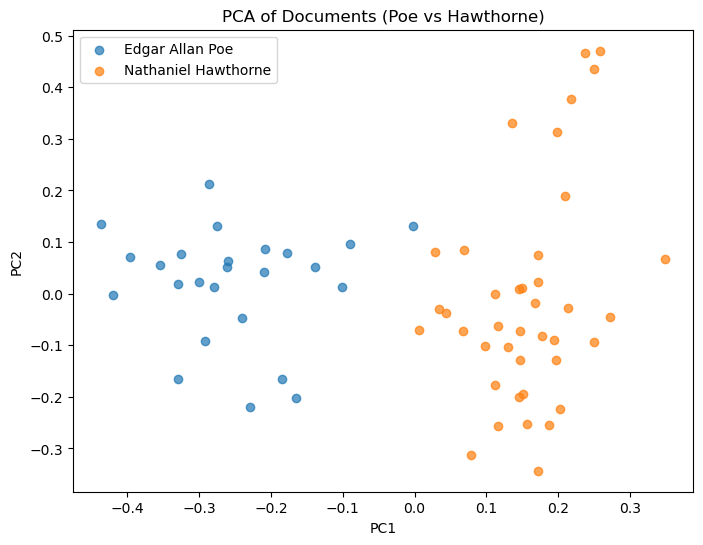

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for author in pca_dcm["author"].unique():
    subset = pca_dcm[pca_dcm["author"] == author]
    plt.scatter(subset["PC1"], subset["PC2"], label=author, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Documents (Poe vs Hawthorne)")
plt.legend()
plt.show()

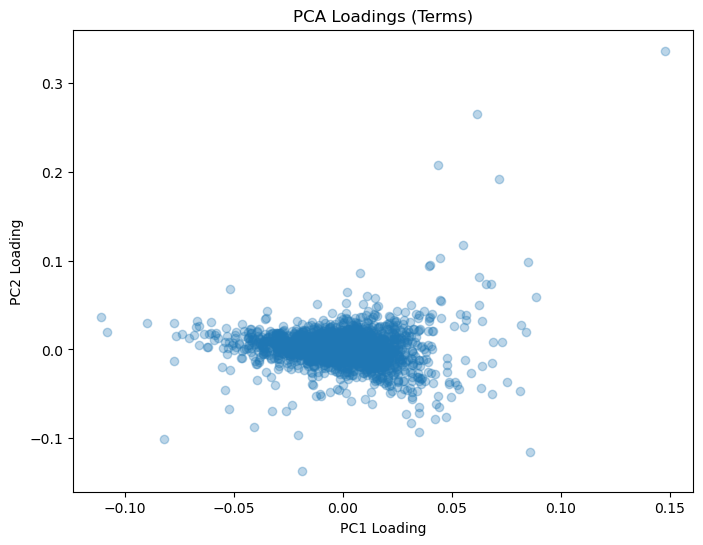

In [66]:
plt.figure(figsize=(8,6))

x = loadings.loc["PC1"]
y = loadings.loc["PC2"]

plt.scatter(x, y, alpha=0.3)

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("PCA Loadings (Terms)")
plt.show()

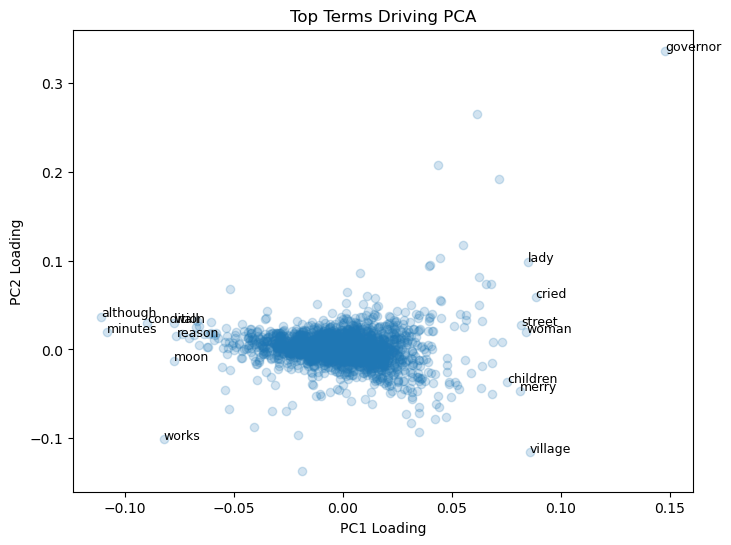

In [67]:
top_terms = loadings.loc["PC1"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.2)

for term in top_terms:
    plt.text(x[term], y[term], term, fontsize=9)

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("Top Terms Driving PCA")
plt.show()

<span style="color:red"> The first principal component shows a strong polarity that separates the works of Edgar Allan Poe and Nathaniel Hawthorne. Poe’s documents cluster on the negative side of PC1, while Hawthorne’s documents cluster on the positive side, indicating that PC1 captures systematic differences in vocabulary and style between the two authors. The polarity suggests a contrast between Poe’s more psychologically intense and gothic language and Hawthorne’s more descriptive, moral, and socially grounded language.
<span>

## PCA Visualization 2 (4)

Include a scatterplot of documents in the space created by the second two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

(INSERT IMAGE HERE)

(INSERT IMAGE HERE)

Briefly describe the nature of the polarity you see in the second component:

(INSERT DESCRIPTION HERE)

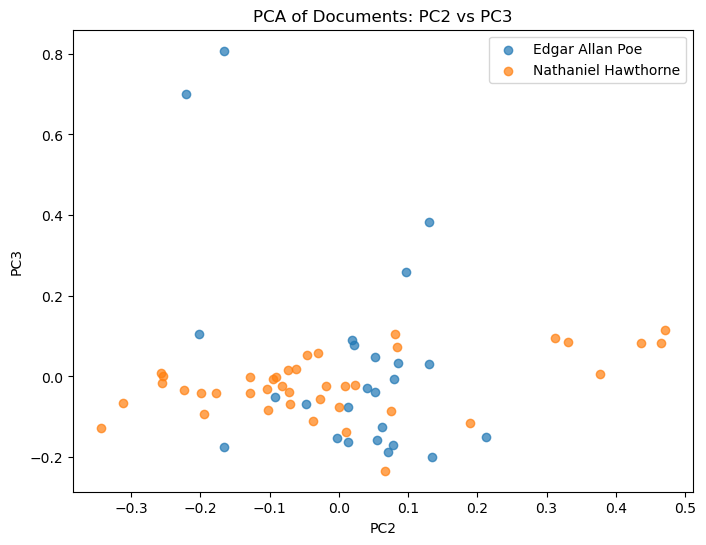

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for author in pca_dcm["author"].unique():
    subset = pca_dcm[pca_dcm["author"] == author]
    plt.scatter(subset["PC2"], subset["PC3"], label=author, alpha=0.7)

plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PCA of Documents: PC2 vs PC3")
plt.legend()
plt.show()

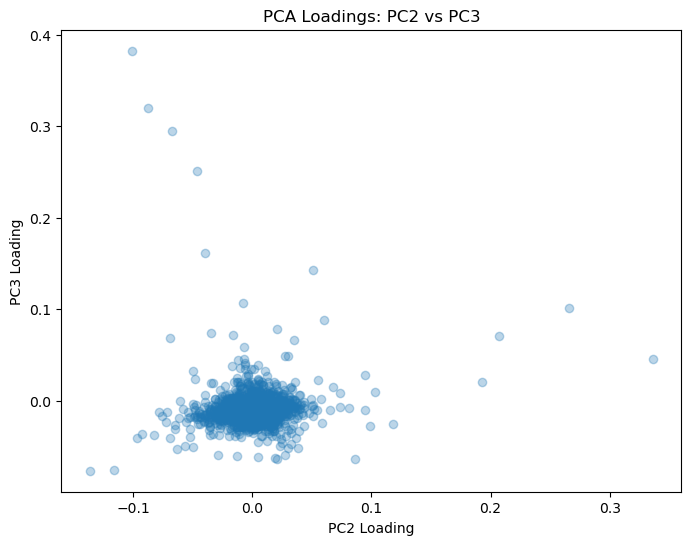

In [69]:
x = loadings.loc["PC2"]
y = loadings.loc["PC3"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.3)

plt.xlabel("PC2 Loading")
plt.ylabel("PC3 Loading")
plt.title("PCA Loadings: PC2 vs PC3")
plt.show()

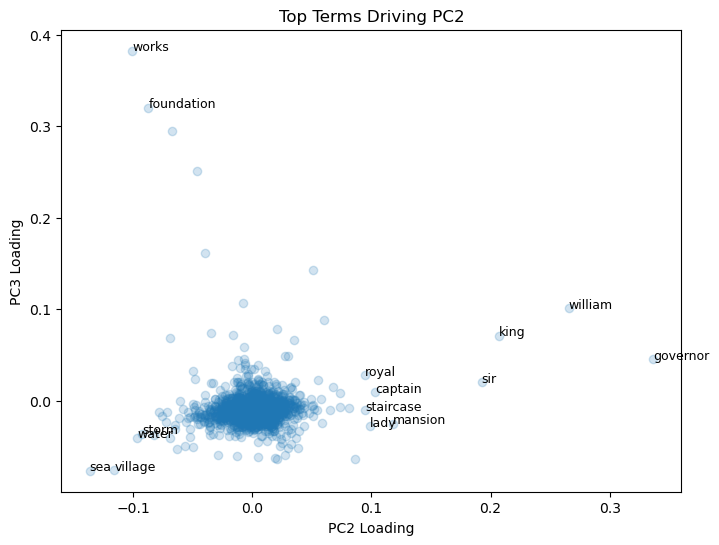

In [70]:
top_terms = loadings.loc["PC2"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2)

for term in top_terms:
    plt.text(x[term], y[term], term, fontsize=9)

plt.xlabel("PC2 Loading")
plt.ylabel("PC3 Loading")
plt.title("Top Terms Driving PC2")
plt.show()

<span style="color:red">
The second principal component exhibits a polarity that is not driven by author but instead reflects thematic differences within the corpus. Words with high positive loadings are associated with formal social structures and authority (e.g., “king,” “governor,” “sir”), while words with negative loadings relate more to natural settings and environmental descriptions (e.g., “sea,” “village,” “storm”). This suggests that PC2 captures a contrast between socially structured, hierarchical contexts and more atmospheric or nature-oriented narrative settings.
<span>

## LDA TOPIC (4)

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- UVA Box URL of count matrix used to create: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- GitHub URL for notebook used to create:
- Delimitter:
- Libary used to compute:
- A description of any filtering, e.g. POS (Nouns and Verbs only):
- Number of components:
- Any other parameters used:
- Top 5 words and best-guess labels for topic five topics by mean document weight:
  - T00:
  - T01:
  - T02:
  - T03:
  - T04:

In [71]:
corpus_filt = corpus[
    (corpus["pos_group"].isin(["NOUN", "VERB"])) &
    (corpus["term_str"].str.len() > 2)
]

In [72]:
dtm_counts = corpus_filt.groupby(["doc_id", "term_str"]).size().unstack(fill_value=0)

In [73]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=10
)

lda.fit(dtm_counts)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [74]:
import numpy as np

terms = dtm_counts.columns

def get_top_words(model, terms, n=5):
    topics = {}
    for i, comp in enumerate(model.components_):
        top_idx = np.argsort(comp)[-n:]
        topics[f"T{i:02d}"] = [terms[j] for j in top_idx]
    return topics

topics = get_top_words(lda, terms, n=5)
topics

{'T00': ['dost', 'gold-bug', 'balloon-hoax', 'portrayed', 'retributions'],
 'T01': ['been', 'have', 'were', 'had', 'was'],
 'T02': ['were', 'been', 'have', 'had', 'was'],
 'T03': ['are', 'works', 'work', 'gutenberg', 'project'],
 'T04': ['were', 'are', 'have', 'had', 'was']}

## LDA THETA (4)

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- GitHub URL for notebook used to create:
- Delimitter:

In [75]:
theta = lda.transform(dtm_counts)

LDA_THETA = pd.DataFrame(
    theta,
    index=dtm_counts.index,
    columns=[f"T{i:02d}" for i in range(theta.shape[1])]
)

LDA_THETA = LDA_THETA.reset_index().rename(columns={"index": "doc_id"})

LDA_THETA = LDA_THETA.merge(
    lib[["doc_id", "author", "title"]],
    on="doc_id",
    how="left"
)

LDA_THETA.head()

,doc_id,T00,T01,T02,T03,T04,author,title
0,DOC001,0.000079,0.000080,0.999682,0.000079,0.000080,Edgar Allan Poe,The Purloined Letter
1,DOC002,0.000744,0.590485,0.364174,0.043828,0.000769,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade
2,DOC003,0.000114,0.000116,0.490589,0.000115,0.509066,Edgar Allan Poe,The Black Cat
3,DOC004,0.000081,0.000083,0.999672,0.000081,0.000083,Edgar Allan Poe,A Descent Into The Maelstrom
4,DOC005,0.000195,0.000199,0.999210,0.000198,0.000198,Edgar Allan Poe,Von Kempelen And His Discovery


In [76]:
LDA_THETA.to_csv("LDA_THETA.csv", index=False)

In [77]:
LDA_THETA[[f"T{i:02d}" for i in range(theta.shape[1])]].sum(axis=1).head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64

## LDA PHI (4)

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- GitHub URL for notebook used to create:
- Delimitter:

In [78]:
import numpy as np

phi = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]

In [79]:
LDA_PHI = pd.DataFrame(
    phi,
    columns=dtm_counts.columns,
    index=[f"T{i:02d}" for i in range(phi.shape[0])]
)

LDA_PHI.head()

term_str,-lantern,....,.....,.fleet,621-9288,:188,_a_,_ab,_abandon_,_absurdities_,...,æolus,æronaut,æronauts,ærostation,æsop,ætna,émeutes,œil_,γελαξμα,λαξμ
T00,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,...,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057
T01,0.000022,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000022,0.000002,0.000002,0.000002,0.000002
T02,0.000003,0.000112,0.000019,0.000019,0.000003,0.000019,0.000019,0.000019,0.000034,0.000003,...,0.000003,0.000034,0.000019,0.000019,0.000003,0.000003,0.000019,0.000019,0.000003,0.000003
T03,0.000023,0.000023,0.000023,0.000023,0.000249,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000136,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023
T04,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000044,...,0.000007,0.000007,0.000007,0.000007,0.000080,0.000007,0.000007,0.000007,0.000044,0.000044


In [80]:
LDA_PHI.to_csv("LDA_PHI.csv")

In [81]:
LDA_PHI.sum(axis=1)

T00    1.0
T01    1.0
T02    1.0
T03    1.0
T04    1.0
dtype: float64

## LDA + PCA Visualization (4)

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

Provide a brief interpretation of what you see.

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

In [82]:
from sklearn.decomposition import PCA

theta_only = LDA_THETA[[col for col in LDA_THETA.columns if col.startswith("T")]]

pca_topics = PCA(n_components=2, random_state=42)
topic_coords = pca_topics.fit_transform(theta_only.T)

In [83]:
topic_df = pd.DataFrame(
    topic_coords,
    columns=["PC1", "PC2"],
    index=theta_only.columns
).reset_index().rename(columns={"index": "topic"})

In [84]:
topic_sizes = theta_only.mean(axis=0)

topic_df["size"] = topic_df["topic"].map(topic_sizes)

In [85]:
dominant_author = {}

for topic in theta_only.columns:
    weights = LDA_THETA[[topic, "author"]]
    dominant_author[topic] = weights.groupby("author")[topic].mean().idxmax()

topic_df["author"] = topic_df["topic"].map(dominant_author)

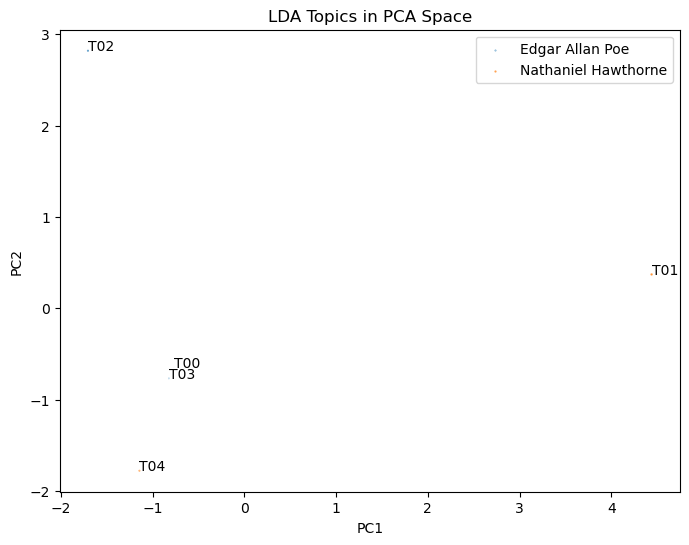

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for author in topic_df["author"].unique():
    subset = topic_df[topic_df["author"] == author]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=subset["size"],
        label=author,
        alpha=0.7
    )

for i, row in topic_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["topic"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LDA Topics in PCA Space")
plt.legend()
plt.show()

<span style="color:red"> The PCA projection of LDA topics reveals meaningful separation among the latent themes in the corpus. One topic (T01) appears strongly isolated along the first component, indicating a distinct thematic structure relative to the others. Another topic (T02) separates along the second component, suggesting a different axis of variation. Some topics (e.g., T00 and T03) cluster closely together, indicating overlapping or related themes. The coloring shows that certain topics are more strongly associated with one author than the other, reinforcing earlier findings that thematic structure varies across authors.
<span>

## Sentiment VOCAB_SENT (4)

Sentiment values associated with a subset of the VOCAB from a curated sentiment lexicon.

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- UVA Box URL for source lexicon: https://app.box.com/s/ub5fk812k15gu1y7svcb3534if1ouv2z
- GitHub URL for notebook used to create:
- Delimitter:

In [87]:
import nltk
from nltk.corpus import opinion_lexicon

nltk.download("opinion_lexicon")

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/mta/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


True

In [88]:
positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())

In [89]:
VOCAB_SENT = vocab[vocab["term_str"].isin(positive_words | negative_words)].copy()

VOCAB_SENT["sentiment"] = VOCAB_SENT["term_str"].apply(
    lambda x: "positive" if x in positive_words else "negative"
)

VOCAB_SENT["sentiment_value"] = VOCAB_SENT["sentiment"].map({
    "positive": 1,
    "negative": -1
})

VOCAB_SENT = VOCAB_SENT[
    ["term_str", "sentiment", "sentiment_value", "n", "df", "dfidf"]
]

VOCAB_SENT.head()

,term_str,sentiment,sentiment_value,n,df,dfidf
30,abnormal,negative,-1,6,5,18.502199
34,abominable,negative,-1,5,4,16.089471
35,abomination,negative,-1,2,2,10.044736
39,abound,positive,1,2,1,6.022368
42,abounds,positive,1,2,2,10.044736


In [90]:
VOCAB_SENT.to_csv("VOCAB_SENT.csv", index=False)

In [91]:
VOCAB_SENT["sentiment"].value_counts()

sentiment
negative    1903
positive    1010
Name: count, dtype: int64

In [92]:
len(VOCAB_SENT)

2913

## Sentiment BOW_SENT (4)

Sentiment values from VOCAB_SENT mapped onto BOW.

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- GitHub URL for notebook used to create:
- Delimitter:

In [93]:
BOW_SENT = bow.merge(
    VOCAB_SENT[["term_str", "sentiment_value"]],
    on="term_str",
    how="inner"
)

In [94]:
BOW_SENT["sent_count"] = BOW_SENT["n"] * BOW_SENT["sentiment_value"]

In [95]:
doc_sentiment = BOW_SENT.groupby("doc_id")["sent_count"].sum().reset_index()
doc_sentiment.head()

,doc_id,sent_count
0,DOC001,-11
1,DOC002,11
2,DOC003,-14
3,DOC004,-82
4,DOC005,32


In [96]:
BOW_SENT.to_csv("BOW_SENT.csv", index=False)

In [97]:
BOW_SENT["sentiment_value"].value_counts()

sentiment_value
-1    9486
 1    6928
Name: count, dtype: int64

In [98]:
doc_sentiment.merge(lib, on="doc_id").groupby("author")["sent_count"].mean()

author
Edgar Allan Poe       -60.360
Nathaniel Hawthorne   -19.525
Name: sent_count, dtype: float64

## Sentiment DOC_SENT (4)

Computed sentiment per bag computed from BOW_SENT.

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- GitHub URL for notebook used to create:
- Delimitter:
- Document bag expressed in terms of OHCO levels:

In [99]:
DOC_SENT = (
    BOW_SENT
    .groupby("doc_id")
    .agg(
        sentiment_sum=("sent_count", "sum"),
        sentiment_words=("n", "sum")
    )
    .reset_index()
)

DOC_SENT = DOC_SENT.merge(
    lib[["doc_id", "author", "title", "n_words"]],
    on="doc_id",
    how="left"
)

DOC_SENT["sentiment_norm"] = DOC_SENT["sentiment_sum"] / DOC_SENT["n_words"]

DOC_SENT.head()

,doc_id,sentiment_sum,sentiment_words,author,title,n_words,sentiment_norm
0,DOC001,-11,391,Edgar Allan Poe,The Purloined Letter,6974,-0.001577
1,DOC002,11,49,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade,735,0.014966
2,DOC003,-14,344,Edgar Allan Poe,The Black Cat,4876,-0.002871
3,DOC004,-82,406,Edgar Allan Poe,A Descent Into The Maelstrom,6928,-0.011836
4,DOC005,32,160,Edgar Allan Poe,Von Kempelen And His Discovery,2768,0.011561


In [100]:
DOC_SENT.to_csv("DOC_SENT.csv", index=False)

In [101]:
DOC_SENT.groupby("author")[["sentiment_sum", "sentiment_norm"]].mean()

,sentiment_sum,sentiment_norm
author,,
Edgar Allan Poe,-60.360,-0.008982
Nathaniel Hawthorne,-19.525,-0.002900


## Sentiment Plot (4)

Plot sentiment over some metric space, such as time.

If you don't have a metric metadata features, plot sentiment over a feature of your choice.

You may use a bar chart or a line graph.

(INSERT IMAGE HERE)

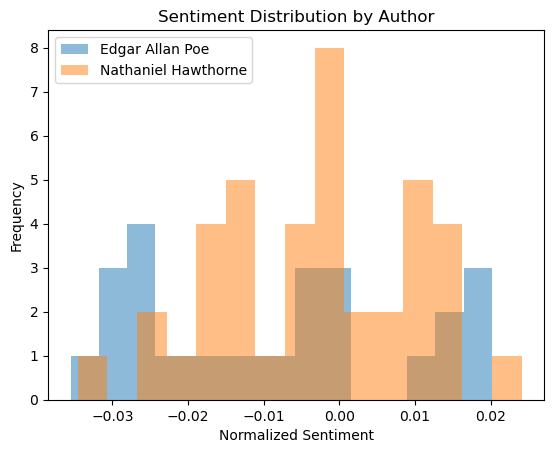

In [102]:
import matplotlib.pyplot as plt

for author in DOC_SENT["author"].unique():
    subset = DOC_SENT[DOC_SENT["author"] == author]
    plt.hist(subset["sentiment_norm"], alpha=0.5, label=author, bins=15)

plt.legend()
plt.title("Sentiment Distribution by Author")
plt.xlabel("Normalized Sentiment")
plt.ylabel("Frequency")
plt.show()

## VOCAB_W2V (4)

A table of word2vec features associated with terms in the VOCAB table.

- UVA Box URL: https://app.box.com/s/w1c855g5x8zzda6uwln9zvszxt20ulj0
- GitHub URL for notebook used to create:
- Delimitter:
- Document bag expressed in terms of OHCO levels:
- Number of features generated:
- The library used to generate the embeddings:

In [103]:
from gensim.models import Word2Vec

sentences = corpus.groupby("doc_id")["term_str"].apply(list).tolist()

In [104]:
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=5,
    min_count=2,
    workers=4
)

In [105]:
import numpy as np

def get_vector(word):
    if word in w2v_model.wv:
        return w2v_model.wv[word]
    else:
        return np.zeros(50)

vectors = vocab["term_str"].apply(get_vector)

VOCAB_W2V = pd.DataFrame(vectors.tolist())
VOCAB_W2V.columns = [f"dim_{i}" for i in range(50)]

VOCAB_W2V["term_str"] = vocab["term_str"].values

VOCAB_W2V.head()

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_41,dim_42,dim_43,dim_44,dim_45,dim_46,dim_47,dim_48,dim_49,term_str
0,0.255568,-0.197362,-0.353930,-0.145726,-0.633276,-1.343468,0.712142,2.007060,-2.884781,-1.093363,...,-0.733424,-0.503309,0.388942,1.459671,-0.415130,-0.394422,-0.570524,1.111996,0.986595,a
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,aaraaf
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,aback
3,0.037905,0.002544,0.016914,-0.018821,-0.005655,-0.025140,-0.039646,-0.000637,-0.062016,0.033486,...,-0.044020,0.003202,0.034703,0.018601,-0.073632,-0.010366,-0.021275,0.001559,0.048151,abandon
4,0.005689,-0.001647,0.023989,-0.020215,0.010158,-0.049073,-0.015801,0.057861,-0.106570,-0.020851,...,-0.057268,-0.012245,0.044986,0.059112,-0.076067,-0.007648,-0.033844,0.036605,0.045492,abandoned


In [106]:
VOCAB_W2V.to_csv("VOCAB_W2V.csv", index=False)

## Word2vec tSNE Plot (4)

Plot word embedding featues in two-dimensions using t-SNE.

Describe a cluster in the plot that captures your attention.

(INSERT IMAGE HERE)

(INSERT DESCRIPTION HERE)

In [109]:
words = vocab.sort_values("n", ascending=False)["term_str"].head(500)

vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
labels = [w for w in words if w in w2v_model.wv]

In [110]:
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X = tsne.fit_transform(np.array(vectors))

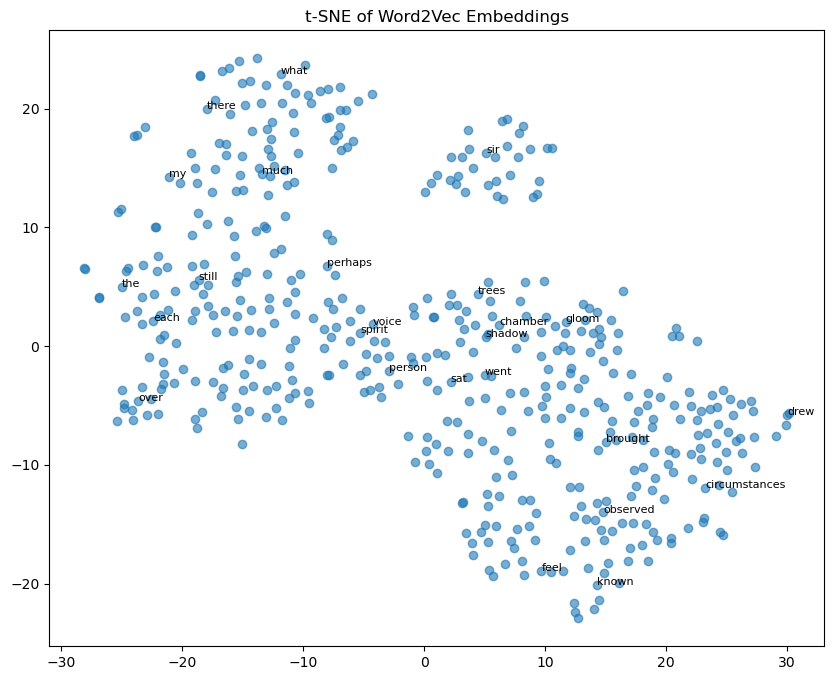

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(X[:,0], X[:,1], alpha=0.6)

# label a subset (not all, or it’s unreadable)
for i in range(0, len(labels), 20):
    plt.text(X[i,0], X[i,1], labels[i], fontsize=8)

plt.title("t-SNE of Word2Vec Embeddings")
plt.show()

<span style="color:red">
The t-SNE visualization shows several loosely defined clusters of semantically related words. One noticeable cluster on the right side contains terms such as “observed,” “known,” “circumstances,” and “brought,” which appear to reflect narrative description and external observation. In contrast, words on the left side of the plot, such as “what,” “there,” “much,” and “still,” are more functional or conversational in nature. This separation suggests that the Word2Vec model is capturing differences between descriptive narrative language and more general or structural language, grouping words based on their contextual usage within the corpus.
<span>

# Riffs

Provde at least three visualizations that combine the preceding model data in interesting ways.

These should provide insight into how features in the LIB table are related. 

The nature of this relationship is left open to you -- it may be correlation, or mutual information, or something less well defined. 

In doing so, consider the following visualization types:

- Hierarchical cluster diagrams
- Heatmaps
- Scatter plots
- KDE plots
- Dispersion plots
- t-SNE plots
- etc.

## Riff 1 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

In [113]:
data = DOC_SENT.copy()
data.columns

Index(['doc_id', 'sentiment_sum', 'sentiment_words', 'author', 'title',
       'n_words', 'sentiment_norm'],
      dtype='object')

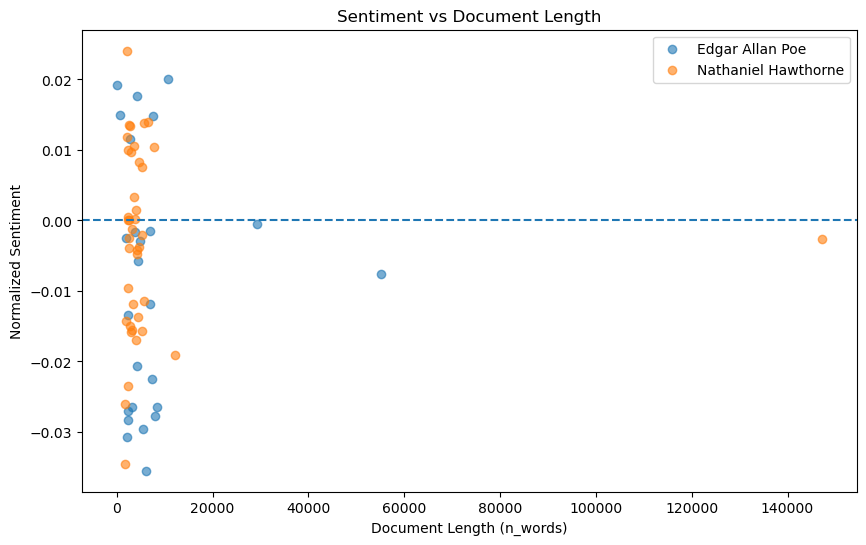

In [114]:
import matplotlib.pyplot as plt

data = DOC_SENT.copy()

plt.figure(figsize=(10,6))

for author in data["author"].unique():
    subset = data[data["author"] == author]
    plt.scatter(
        subset["n_words"],
        subset["sentiment_norm"],
        alpha=0.6,
        label=author
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Document Length (n_words)")
plt.ylabel("Normalized Sentiment")
plt.title("Sentiment vs Document Length")
plt.legend()
plt.show()

<span style="color:red">
The scatter plot shows little to no strong relationship between document length and normalized sentiment. Most documents, regardless of length, cluster near slightly negative sentiment values, indicating that both authors tend to use more negative than positive language overall. However, a clear author-level pattern emerges: Edgar Allan Poe’s works generally skew more negative than Nathaniel Hawthorne’s across comparable document lengths. The presence of a few very long documents does not materially change this pattern, suggesting that sentiment differences are driven more by authorial style than by document size.
<span>

## Riff 2 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

In [115]:
top_terms = vocab.sort_values("dfidf", ascending=False)["term_str"].head(20)

In [117]:
dtm_subset = dtm[top_terms].copy()

In [118]:
dtm_subset["author"] = lib["author"].values

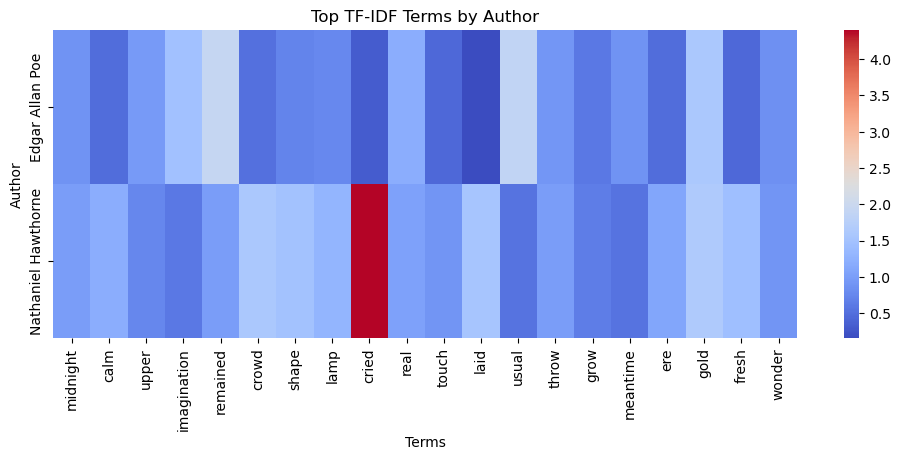

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.heatmap(author_term, cmap="coolwarm")

plt.title("Top TF-IDF Terms by Author")
plt.xlabel("Terms")
plt.ylabel("Author")
plt.show()

<span style="color:red">
The heatmap suggests a clear stylistic distinction between Edgar Allan Poe and Nathaniel Hawthorne based on their use of high TF-IDF terms. Hawthorne stands out with a few highly weighted words, most notably “cried,” indicating a stronger emphasis on emotionally explicit language and dialogue. His relatively higher weights on terms like “shape,” “lamp,” and “gold” further point to a descriptive style that focuses on physical settings and observable details. In contrast, Poe’s TF-IDF values are more evenly distributed across terms, with no single word dominating, which suggests a more controlled and consistent vocabulary. His use of words such as “midnight,” “imagination,” and “calm” reflects a more internal and psychological tone. Overall, the visualization indicates that Hawthorne’s writing leans toward expressive and descriptive narration, while Poe’s style is more restrained and introspective.
<span>

## Riff 3 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

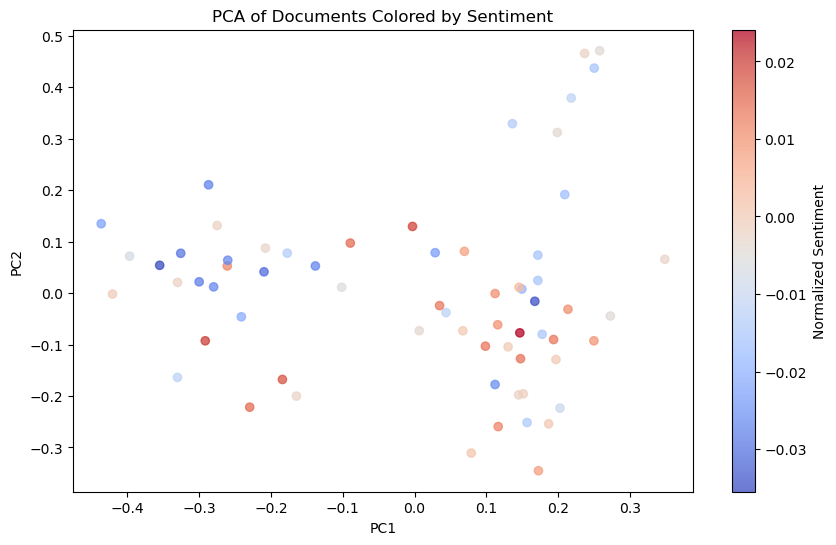

In [123]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
doc_pca = pca.fit_transform(tfidf_l2)

pca_df = pd.DataFrame(doc_pca, columns=["PC1", "PC2"])
pca_df["doc_id"] = tfidf_l2.index

data = pca_df.merge(
    DOC_SENT[["doc_id", "author", "sentiment_norm"]],
    on="doc_id",
    how="left"
)

plt.figure(figsize=(10, 6))

sc = plt.scatter(
    data["PC1"],
    data["PC2"],
    c=data["sentiment_norm"],
    cmap="coolwarm",
    alpha=0.75
)

plt.colorbar(sc, label="Normalized Sentiment")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Documents Colored by Sentiment")
plt.show()

<span style="color:red">
This visualization overlays normalized sentiment onto the PCA representation of documents, revealing that sentiment does not strongly drive the primary structure of the corpus. While there is some local variation in color—indicating pockets of more positive or negative documents—the dominant separation along the principal components remains largely unchanged, suggesting it is driven more by stylistic or thematic differences (such as author) rather than emotional tone. Both positive and negative sentiment values are distributed across the space, indicating that sentiment varies within each author’s work rather than cleanly separating them. Overall, sentiment appears to be a secondary characteristic of the documents, not the main factor organizing their similarity.
<span>

# Interpretation (4)

Describe something interesting about your corpus that you discovered during the process of completing this assignment.

At a minumum, use 250 words, but you may use more. You may also add images if you'd like.

(INSERT INTERPRETATION HERE)

<span style="color:red">
One of the most interesting findings from this analysis is how clearly stylistic differences between Edgar Allan Poe and Nathaniel Hawthorne emerge across multiple modeling approaches, even when those methods are not explicitly designed to separate authors. In the PCA visualizations, documents cluster almost cleanly by author along the first principal component, suggesting that underlying vocabulary usage alone is sufficient to distinguish between the two writers. This separation is not driven by sentiment, as shown in the PCA overlay colored by normalized sentiment values. Instead, sentiment appears to vary within each author’s body of work rather than acting as a primary differentiator between them.

The TF-IDF analysis further reinforces this distinction. Hawthorne’s writing is characterized by a few highly weighted, distinctive terms—such as “cried”—which suggests a more expressive and descriptive narrative style. In contrast, Poe’s vocabulary is more evenly distributed, indicating a more controlled and consistent use of language. This aligns with literary expectations: Poe’s works tend to focus on psychological intensity and internal states, while Hawthorne often emphasizes external settings and character interactions.

Additionally, the Word2Vec and t-SNE visualizations reveal meaningful semantic groupings within the corpus. Clusters of words related to setting (e.g., “chamber,” “shadow,” “gloom”) and social structure (e.g., “king,” “sir,” “governor”) suggest that the model is capturing thematic dimensions beyond simple word frequency. These embeddings highlight how both authors operate within similar thematic spaces, yet differ in how they deploy language within those spaces.

Overall, the analysis demonstrates that authorial style is a dominant signal in this corpus, overshadowing sentiment and even some thematic variation. The consistency of this pattern across multiple techniques—PCA, TF-IDF, and Word2Vec—provides strong evidence that quantitative text analysis can effectively capture and differentiate literary style.
<span>